In [2]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null
!pip install -q pyspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import pandas as pd
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from functools import reduce
from pyspark.sql import Row

print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PySpark:", pyspark.__version__)

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
PySpark: 4.0.4


# 1. Carga, armonización y calidad de datos

In [5]:
spark = (
    SparkSession.builder
    .appName("ENEIC_Lab7")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

#lectura
BASE = "/content/drive/MyDrive/Lab7"

ARCHIVOS = {
    "2025_I":  {"path": f"{BASE}/Base-de-datos-Personas-ENEIC-I-2025.xlsx",   "periodo": "2025T1", "anio": 2025, "tri": 1},
    "2025_II": {"path": f"{BASE}/Base-de-datos-Personas-ENEIC-II-2025.xlsx",  "periodo": "2025T2", "anio": 2025, "tri": 2},
    "2025_III":{"path": f"{BASE}/Base-de-datos-Personas-ENEIC-III-2025.xlsx", "periodo": "2025T3", "anio": 2025, "tri": 3},
    "2025_IV": {"path": f"{BASE}/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",  "periodo": "2025T4", "anio": 2025, "tri": 4},
    "2026_I":  {"path": f"{BASE}/Base-de-datos-Personas-ENEIC-I-2026.xlsx",  "periodo": "2026T1", "anio": 2026, "tri": 1},
}

RENOMBRE = { #excel-nom alanlitco
    "P05D01":  "salario_mensual",
    "P02A03":  "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16":  "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS":"ocupado",
    "NUM_HOGAR":"num_hogar",
    "NUM_PERSONA":"num_persona",
    "FACTOR":  "factor",
    "ANIO":    "anio",
    "TRIMESTRE":"trimestre_original"
}

COLS_REQUERIDAS = list(RENOMBRE.keys())

TIPOS = {
    "salario_mensual":      "double",
    "edad":                 "int",
    "antiguedad_anios":     "int",
    "antiguedad_meses":     "int",
    "horas_semanales":      "double",
    "nivel_educativo":      "int",
    "categoria_ocupacional":"int",
    "dominio":              "int",
    "ocupado":              "int",
    "num_hogar":            "int",
    "num_persona":          "int",
    "factor":               "double",
    "anio":                 "int",
    "trimestre_original":   "int"
}

In [6]:
def cargar_periodo(meta, cols_comunes=None):
    pdf = pd.read_excel(meta["path"], dtype=str, engine="openpyxl")
    pdf.columns = pdf.columns.str.strip()

    presentes = [c for c in COLS_REQUERIDAS if c in pdf.columns]
    pdf = pdf[presentes].copy()

    pdf = pdf.rename(columns=RENOMBRE)

    #limpieza
    pdf = pdf.replace(
        to_replace=["NaN", "nan", "NAN", "None", "none", "", " ", "."],
        value=None
    )

    pdf["periodo_archivo"] = meta["periodo"]
    pdf["anio_archivo"] = meta["anio"]
    pdf["trimestre_calendario"] = meta["tri"]
    pdf["archivo_origen"] = meta["periodo"]

    if cols_comunes is not None:
        pdf = pdf[[c for c in cols_comunes if c in pdf.columns]]

    sdf = spark.createDataFrame(pdf)
    return sdf

In [7]:
#carga de archivos
#2025
dfs_2025 = []
for key in ["2025_I", "2025_II", "2025_III", "2025_IV"]:
    sdf = cargar_periodo(ARCHIVOS[key])
    dfs_2025.append(sdf)
    print(f"{key}: {sdf.count()} filas | {len(sdf.columns)} columnas")

cols_comunes = set(dfs_2025[0].columns)
for d in dfs_2025[1:]:
    cols_comunes &= set(d.columns)
cols_comunes = sorted(cols_comunes)
print(f"\nColumnas comunes: {len(cols_comunes)}")

dfs_2025 = [d.select(*cols_comunes) for d in dfs_2025]

df_2025 = reduce(lambda a, b: a.unionByName(b), dfs_2025)
print("Total 2025:", df_2025.count())
df_2025.printSchema()
#2026
df_2026 = cargar_periodo(ARCHIVOS["2026_I"], cols_comunes=cols_comunes)
print("2026T1:", df_2026.count())


#data frames
def preparar(df):
    for col, tipo in TIPOS.items():
        if col in df.columns:
            df = df.withColumn(col, F.expr(f"try_cast(`{col}` as {tipo})"))
    return df

df_2025 = preparar(df_2025)
df_2026 = preparar(df_2026)


df_2025 = df_2025.withColumn(
    "antiguedad",
    F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)
)
df_2026 = df_2026.withColumn(
    "antiguedad",
    F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)
)

def aplicar_filtros(df):
    return df.filter(
        (F.col("edad").isNotNull()) & (F.col("edad") >= 15) &
        (F.col("antiguedad").isNotNull()) & (F.col("antiguedad") >= 0) &
        (F.col("antiguedad_meses").between(0, 11)) &
        (F.col("antiguedad") <= F.col("edad")) &
        (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168) &
        (F.col("ocupado") == 1) &
        (F.col("categoria_ocupacional").isin(1, 2, 3, 4)) &
        (F.col("salario_mensual").isNotNull()) & (F.col("salario_mensual") > 0)
    )

df_2025_f = aplicar_filtros(df_2025)
df_2026_f = aplicar_filtros(df_2026)

print("2025 filtrado:", df_2025_f.count())
print("2026 filtrado:", df_2026_f.count())

2025_I: 51588 filas | 18 columnas
2025_II: 51167 filas | 18 columnas
2025_III: 51583 filas | 18 columnas
2025_IV: 49338 filas | 18 columnas

Columnas comunes: 18
Total 2025: 203676
root
 |-- anio: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- antiguedad_anios: string (nullable = true)
 |-- antiguedad_meses: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- edad: string (nullable = true)
 |-- factor: string (nullable = true)
 |-- horas_semanales: string (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- num_hogar: string (nullable = true)
 |-- num_persona: string (nullable = true)
 |-- ocupado: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- salario_mensual: string (nullable = true)
 |-- trimestre_calendario: long (nullable = true)
 |-- trimestre_original: string (nullable = true)

2026T1: 49843
20

In [8]:
#parquet
df_2025_f.write.mode("overwrite").parquet(f"{BASE}/parquet/eneic_2025")
df_2026_f.write.mode("overwrite").parquet(f"{BASE}/parquet/eneic_2026")

df_2025_parquet = spark.read.parquet(f"{BASE}/parquet/eneic_2025")
df_2026_parquet = spark.read.parquet(f"{BASE}/parquet/eneic_2026")

In [9]:
print("=== ESQUEMA ===")
df_2025_f.printSchema()

print("\n=== 5 REGISTROS ===")
df_2025_f.show(5, truncate=False)

=== ESQUEMA ===
root
 |-- anio: integer (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- antiguedad_anios: integer (nullable = true)
 |-- antiguedad_meses: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- categoria_ocupacional: integer (nullable = true)
 |-- dominio: integer (nullable = true)
 |-- edad: integer (nullable = true)
 |-- factor: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: integer (nullable = true)
 |-- num_hogar: integer (nullable = true)
 |-- num_persona: integer (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- trimestre_calendario: long (nullable = true)
 |-- trimestre_original: integer (nullable = true)
 |-- antiguedad: double (nullable = true)


=== 5 REGISTROS ===
+----+------------+----------------+----------------+--------------+---------------------+-------+----+----

In [10]:
#conteo anetes/despues de filtros
resumen = []
for key in ["2025_I", "2025_II", "2025_III", "2025_IV"]:
    sdf = cargar_periodo(ARCHIVOS[key])
    sdf = preparar(sdf)
    sdf = sdf.withColumn(
        "antiguedad",
        F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)
    )
    antes = sdf.count()
    despues = aplicar_filtros(sdf).count()
    resumen.append((key, antes, despues, antes - despues))

resumen_df = spark.createDataFrame(
    resumen, ["archivo", "antes", "despues", "excluidos"]
)
resumen_df.show()

sdf26 = cargar_periodo(ARCHIVOS["2026_I"])
sdf26 = preparar(sdf26)
sdf26 = sdf26.withColumn(
    "antiguedad",
    F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)
)
print(f"2026_I: antes={sdf26.count()} despues={aplicar_filtros(sdf26).count()}")


#faltantes
total = df_2025.count()
faltantes = []
for col in df_2025.columns:
    nulos = df_2025.filter(F.col(col).isNull()).count()
    faltantes.append((col, nulos, round(100 * nulos / total, 2)))

falt_df = spark.createDataFrame(faltantes, ["variable", "nulos", "porcentaje"])
falt_df.orderBy(F.desc("nulos")).show(30, truncate=False)

+--------+-----+-------+---------+
| archivo|antes|despues|excluidos|
+--------+-----+-------+---------+
|  2025_I|51588|  13419|    38169|
| 2025_II|51167|  13492|    37675|
|2025_III|51583|  13450|    38133|
| 2025_IV|49338|  12664|    36674|
+--------+-----+-------+---------+

2026_I: antes=49843 despues=13258
+---------------------+------+----------+
|variable             |nulos |porcentaje|
+---------------------+------+----------+
|antiguedad_anios     |115454|56.69     |
|ocupado              |115454|56.69     |
|antiguedad_meses     |115454|56.69     |
|antiguedad           |115454|56.69     |
|categoria_ocupacional|115454|56.69     |
|nivel_educativo      |26344 |12.93     |
|anio                 |0     |0.0       |
|horas_semanales      |0     |0.0       |
|anio_archivo         |0     |0.0       |
|num_hogar            |0     |0.0       |
|archivo_origen       |0     |0.0       |
|num_persona          |0     |0.0       |
|dominio              |0     |0.0       |
|periodo_arch

In [11]:
def excluidos_paso_a_paso(df):
    pasos = []
    d = df
    pasos.append(("inicio", d.count()))

    d = d.filter((F.col("edad").isNotNull()) & (F.col("edad") >= 15))
    pasos.append(("edad >= 15", d.count()))

    d = d.filter((F.col("antiguedad").isNotNull()) & (F.col("antiguedad") >= 0))
    pasos.append(("antiguedad >= 0", d.count()))

    d = d.filter(F.col("antiguedad_meses").between(0, 11))
    pasos.append(("meses 0-11", d.count()))

    d = d.filter(F.col("antiguedad") <= F.col("edad"))
    pasos.append(("antiguedad <= edad", d.count()))

    d = d.filter((F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168))
    pasos.append(("horas 1-168", d.count()))

    d = d.filter(F.col("ocupado") == 1)
    pasos.append(("ocupado = 1", d.count()))

    d = d.filter(F.col("categoria_ocupacional").isin(1,2,3,4))
    pasos.append(("cat_ocup 1-4", d.count()))

    d = d.filter((F.col("salario_mensual").isNotNull()) & (F.col("salario_mensual") > 0))
    pasos.append(("salario > 0", d.count()))

    return pasos

for paso, n in excluidos_paso_a_paso(df_2025):
    print(f"{paso:20s} -> {n:,}")

inicio               -> 203,676
edad >= 15           -> 140,790
antiguedad >= 0      -> 88,222
meses 0-11           -> 88,222
antiguedad <= edad   -> 88,222
horas 1-168          -> 88,222
ocupado = 1          -> 88,222
cat_ocup 1-4         -> 53,025
salario > 0          -> 53,025


In [12]:
from pyspark.sql.functions import col, count, collect_list, struct
#unicidad
dup = (df_2025_f
       .groupBy("periodo_archivo", "num_hogar", "num_persona")
       .count()
       .filter("count > 1"))

print("Grupos duplicados:", dup.count())
dup.orderBy(F.desc("count")).show(20, truncate=False)

if dup.count() > 0:
    claves_dup = dup.select("periodo_archivo","num_hogar","num_persona")
    muestra = df_2025_f.join(claves_dup, ["periodo_archivo","num_hogar","num_persona"], "inner")
    muestra.show(20, truncate=False)


dups_detalle = (df_2025_f
    .groupBy("periodo_archivo", "num_hogar", "num_persona")
    .agg(count("*").alias("n"),
         collect_list(struct(*[c for c in df_2025_f.columns
                                if c not in ("periodo_archivo","num_hogar","num_persona")]
                            )).alias("filas"))
    .filter("n > 1"))

dups_detalle.show(5, truncate=False)

Grupos duplicados: 0
+---------------+---------+-----------+-----+
|periodo_archivo|num_hogar|num_persona|count|
+---------------+---------+-----------+-----+
+---------------+---------+-----------+-----+

+---------------+---------+-----------+---+-----+
|periodo_archivo|num_hogar|num_persona|n  |filas|
+---------------+---------+-----------+---+-----+
+---------------+---------+-----------+---+-----+



*  ¿Por qué IV de 2025 no puede apilarse por posición de columnas con  los otros archivos?

Debido a que la cantidad de filas es mayor que otros trimestres, apliar es alinar por orden no por orden. Esto llevaría a que hubiera errores de donde se colocarían los datos.

*  ¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?

Un dato ausente puede darse por que no hay un respuesta a la pregunta por que en la estructura de estas no se consideró un escenario que le corresponda (por ejemplo gente que no trabaja) y una pregunta no registrada puede deberse a un error de reclección de datos o que el encuestado simplemente no respondío ya sea por no "saber" que responder o negarse a hacerlo.

*   ¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?

Porque al ser entrevistada en este plazo de tiempo pudo darse algún cambio en la situación laboral de la persona, como cambiar de trabajo, cambios en el salario o tiempo de trabajo.

*   ¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?

Debido a los filtros aplicados a los datos, dejando de lado a aquellos que no cumplan estos filtros.



# 2. Estadística descriptiva y preguntas de exploración

In [13]:
vars_num = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def stats_col(df, col):
    q = df.approxQuantile(col, [0.25, 0.5, 0.75, 0.95], 0.001)
    agg = df.agg(
        F.count(col).alias("n"),
        F.mean(col).alias("media"),
        F.stddev(col).alias("std"),
        F.min(col).alias("min"),
        F.max(col).alias("max")
    ).collect()[0]
    return Row(
        variable = col,
        n = int(agg["n"]) if agg["n"] is not None else None,
        media = float(agg["media"]) if agg["media"] is not None else None,
        mediana = float(q[1]) if q else None,
        std = float(agg["std"])   if agg["std"] is not None else None,
        min = float(agg["min"])   if agg["min"] is not None else None,
        max = float(agg["max"])   if agg["max"] is not None else None,
        p25 = float(q[0]) if q else None,
        p75 = float(q[2]) if q else None,
        p95 = float(q[3]) if q else None
    )

resumen_stats = spark.createDataFrame([stats_col(df_2025_f, c) for c in vars_num])
resumen_stats.show(truncate=False)



+---------------+-----+------------------+-------+------------------+----+-------+------+------+------------------+
|variable       |n    |media             |mediana|std               |min |max    |p25   |p75   |p95               |
+---------------+-----+------------------+-------+------------------+----+-------+------+------+------------------+
|salario_mensual|53025|3421.6842055634133|3000.0 |2902.1089638220783|1.0 |99000.0|1800.0|4000.0|8000.0            |
|edad           |53025|35.187647336162186|33.0   |13.520901607119615|15.0|89.0   |24.0  |44.0  |61.0              |
|antiguedad     |53025|5.558827597045419 |2.0    |7.831017178756599 |0.0 |70.0   |0.5   |7.0   |21.416666666666668|
|horas_semanales|53025|46.30740216878831 |45.0   |18.630406843525044|1.0 |126.0  |40.0  |55.0  |80.0              |
+---------------+-----+------------------+-------+------------------+----+-------+------+------+------------------+



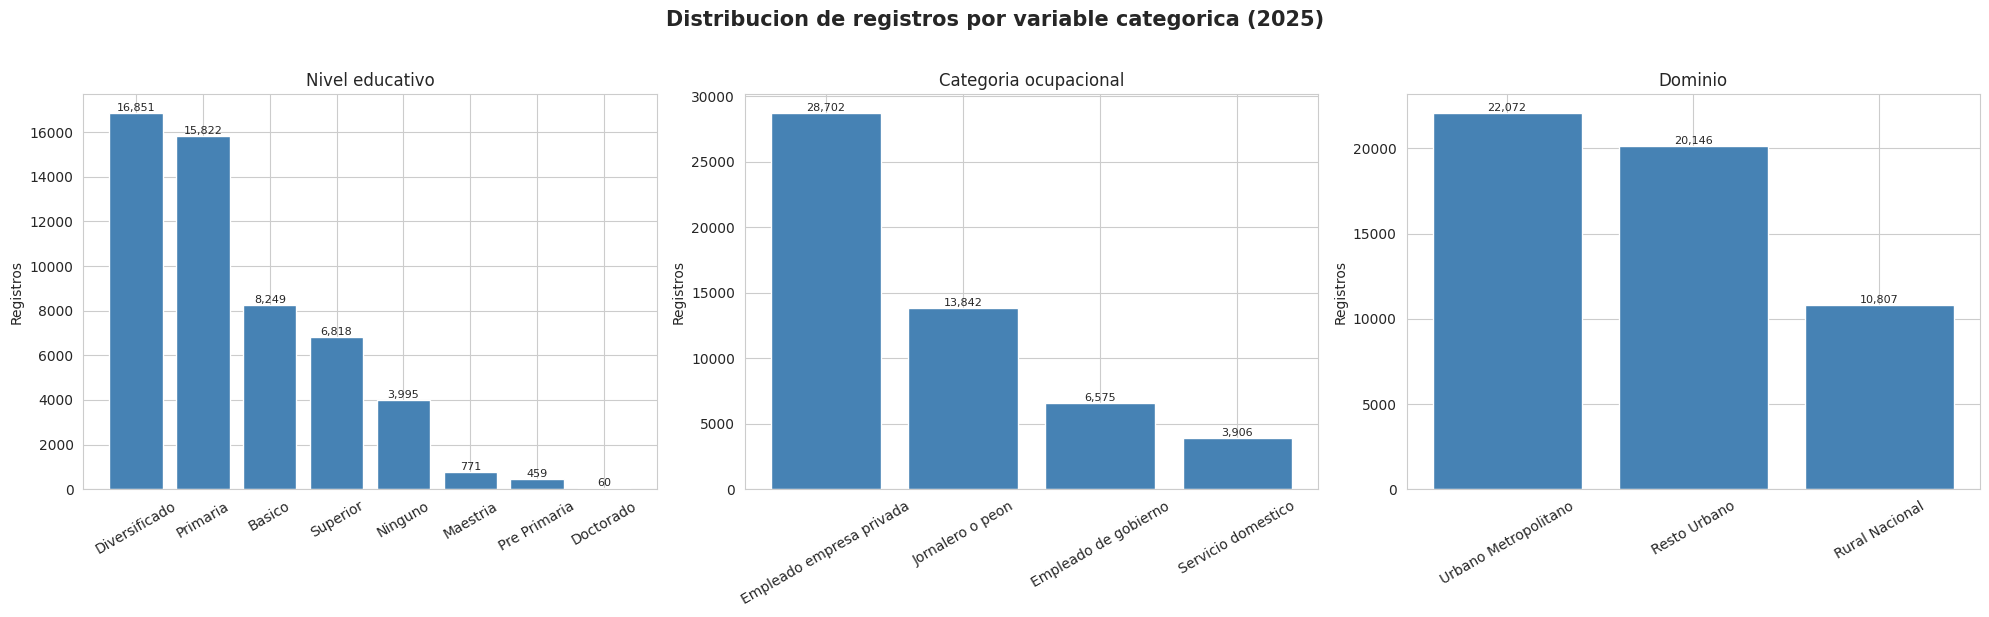

,nivel_educativo,descripcion,count,porcentaje
0,4,Diversificado,"16,851",31.78%
1,2,Primaria,"15,822",29.84%
2,3,Basico,"8,249",15.56%
3,5,Superior,"6,818",12.86%
4,0,Ninguno,"3,995",7.53%
5,6,Maestria,771,1.45%
6,1,Pre Primaria,459,0.87%
7,7,Doctorado,60,0.11%


,categoria_ocupacional,descripcion,count,porcentaje
0,2,Empleado empresa privada,"28,702",54.13%
1,3,Jornalero o peon,"13,842",26.10%
2,1,Empleado de gobierno,"6,575",12.40%
3,4,Servicio domestico,"3,906",7.37%


,dominio,descripcion,count,porcentaje
0,1,Urbano Metropolitano,"22,072",41.63%
1,2,Resto Urbano,"20,146",37.99%
2,3,Rural Nacional,"10,807",20.38%


In [24]:
#distribucion var. categoricas
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

ETIQ_EDUC = {
    0: "Ninguno",
    1: "Pre Primaria",
    2: "Primaria",
    3: "Basico",
    4: "Diversificado",
    5: "Superior",
    6: "Maestria",
    7: "Doctorado"
}
ETIQ_CAT = {
    1: "Empleado de gobierno",
    2: "Empleado empresa privada",
    3: "Jornalero o peon",
    4: "Servicio domestico",
}
ETIQ_DOM = {
    1: "Urbano Metropolitano",
    2: "Resto Urbano",
    3: "Rural Nacional"
}

def frec(col, etiquetas=None):
    d = (df_2025_f.groupBy(col).count()
         .orderBy(F.desc("count")).toPandas())
    d["porcentaje"] = (d["count"] / d["count"].sum() * 100).round(2)
    if etiquetas is not None:
        d["descripcion"] = d[col].map(etiquetas).fillna("DESCONOCIDO")
        d = d[[col, "descripcion", "count", "porcentaje"]]
    return d

frec_educ = frec("nivel_educativo", ETIQ_EDUC)
frec_cat  = frec("categoria_ocupacional", ETIQ_CAT)
frec_dom  = frec("dominio", ETIQ_DOM)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datos = [
    (frec_educ, "Nivel educativo",         ETIQ_EDUC, "nivel_educativo"),
    (frec_cat,  "Categoria ocupacional",   ETIQ_CAT,  "categoria_ocupacional"),
    (frec_dom,  "Dominio",                 ETIQ_DOM,  "dominio"),
]

for ax, (d, titulo, etiq, col) in zip(axes, datos):
    etiquetas_x = d[col].map(etiq).fillna("DESCONOCIDO").astype(str)
    barras = ax.bar(etiquetas_x, d["count"], color="steelblue", edgecolor="white")

    for b, v in zip(barras, d["count"]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                f"{v:,}", ha="center", va="bottom", fontsize=8)

    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Distribucion de registros por variable categorica (2025)",
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

display(frec_educ.style.format({"count": "{:,}", "porcentaje": "{:.2f}%"})
                 .set_caption("Distribucion por nivel educativo"))
print("")
display(frec_cat.style.format({"count": "{:,}", "porcentaje": "{:.2f}%"})
                .set_caption("Distribucion categoria ocupacional"))
print("")
display(frec_dom.style.format({"count": "{:,}", "porcentaje": "{:.2f}%"})
                .set_caption("Distribucion dominio"))

Los registros en categorías educativas muestran una mayor concentración en los niveles de diversificado y primaria mientras que los doctorados son la categoría con menos concentración al tan solo contar con un total de 60 individuos.

La mayoría de la concentracion en la categoria ocupacional es el sector privado, mientras que la minoría cubre los trabajos domésticos. Además de que mayormente se dio en el area Urbano metropolitano.

N muestra gráfico: 2680


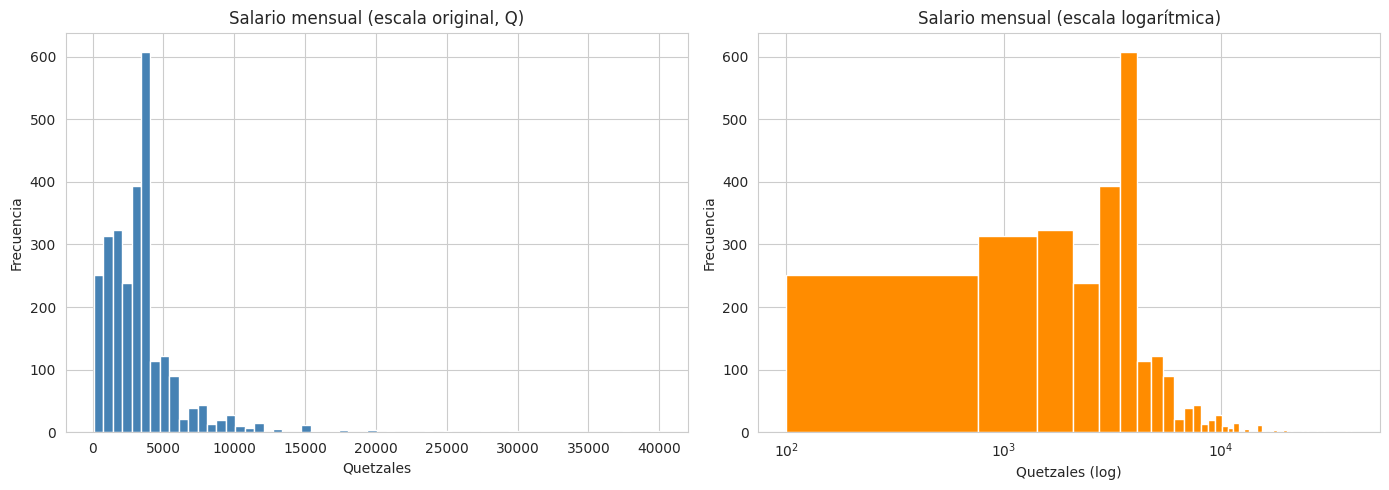

Media:   Q 3,421.68
Mediana: Q 3,000.00
Diferencia (media - mediana): Q 421.68
Ratio media/mediana: 1.14


In [15]:
#muestra pra grafica
sal_pd = (df_2025_f
          .select("salario_mensual")
          .sample(fraction=0.05, seed=42)
          .toPandas())

print("N muestra gráfico:", len(sal_pd))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sal_pd["salario_mensual"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Salario mensual (escala original, Q)")
axes[0].set_xlabel("Quetzales")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(sal_pd["salario_mensual"].clip(lower=1), bins=60,
             color="darkorange", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Salario mensual (escala logarítmica)")
axes[1].set_xlabel("Quetzales (log)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

#Media vs mediana todo
media   = df_2025_f.agg(F.mean("salario_mensual")).collect()[0][0]
mediana = df_2025_f.approxQuantile("salario_mensual", [0.5], 0.001)[0]

print(f"Media:   Q {media:,.2f}")
print(f"Mediana: Q {mediana:,.2f}")
print(f"Diferencia (media - mediana): Q {media - mediana:,.2f}")
print(f"Ratio media/mediana: {media/mediana:.2f}")

Las distribuciones de salarios es bastante asimétrica, siendo una gran mayoría aquellos que ganan menos de Q 5000.00, cosa que mayormente indica la sitaucion económica de los guatemaltecos que trabajan y explica porque muchos pueden llegar a pasar problemas mes a mes ya que el costo de vida ha aumentado recientemente pero los salarios se mantienen bajos mayormente.

La diferencia entre la media y la mediana es de unos Q421.68, siendo asi que podemos ver que la media es algo más robusto para una descripción del salario que la mediana.


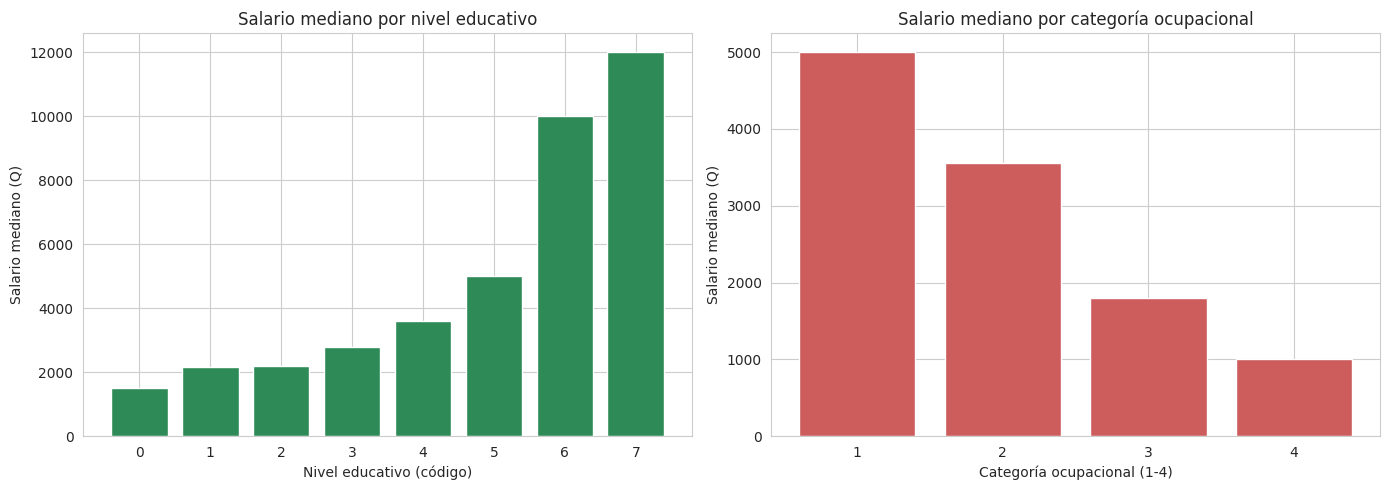

Salario mediano por nivel educativo:

Salario mediano por categoría ocupacional:


,categoria_ocupacional,salario_mediano,n
0,1,5000.0,6575
1,2,3555.0,28702
2,3,1800.0,13842
3,4,1000.0,3906


In [16]:
def mediana_por_grupo(df, grupo, target="salario_mensual"):
    filas = []
    valores = [r[0] for r in df.select(grupo).distinct().collect() if r[0] is not None]
    for v in sorted(valores):
        sub = df.filter(F.col(grupo) == v)
        q = sub.approxQuantile(target, [0.5], 0.001)
        n = sub.count()
        if q:
            filas.append((v, float(q[0]), n))
    return pd.DataFrame(filas, columns=[grupo, "salario_mediano", "n"])

med_educ = mediana_por_grupo(df_2025_f, "nivel_educativo")
med_cat  = mediana_por_grupo(df_2025_f, "categoria_ocupacional")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(med_educ["nivel_educativo"].astype(str),
            med_educ["salario_mediano"], color="seagreen")
axes[0].set_title("Salario mediano por nivel educativo")
axes[0].set_xlabel("Nivel educativo (código)")
axes[0].set_ylabel("Salario mediano (Q)")

axes[1].bar(med_cat["categoria_ocupacional"].astype(str),
            med_cat["salario_mediano"], color="indianred")
axes[1].set_title("Salario mediano por categoría ocupacional")
axes[1].set_xlabel("Categoría ocupacional (1-4)")
axes[1].set_ylabel("Salario mediano (Q)")

plt.tight_layout()
plt.show()

print("Salario mediano por nivel educativo:")
med_educ
print("\nSalario mediano por categoría ocupacional:")
med_cat

Naturalmente el nivel educativo es un impulsor a obtener buenos salarios, sin embargo la brecha entre los salarios medios de aquellos que completaron maestrías y doctorados es bastante grande llegando a ser el doble que el salario de aquellos con solamente educación superior.

El sector privado lidera en las categorias ocupacionales según su salario medio. Mientras que el servicio doméstico no llega ni a la mitad del salario minimo.

   trimestre_calendario      n  salario_mediano  salario_medio
0                     1  13419           3000.0    3315.631940
1                     2  13492           3000.0    3364.570783
2                     3  13450           3200.0    3469.074647
3                     4  12664           3200.0    3544.574937



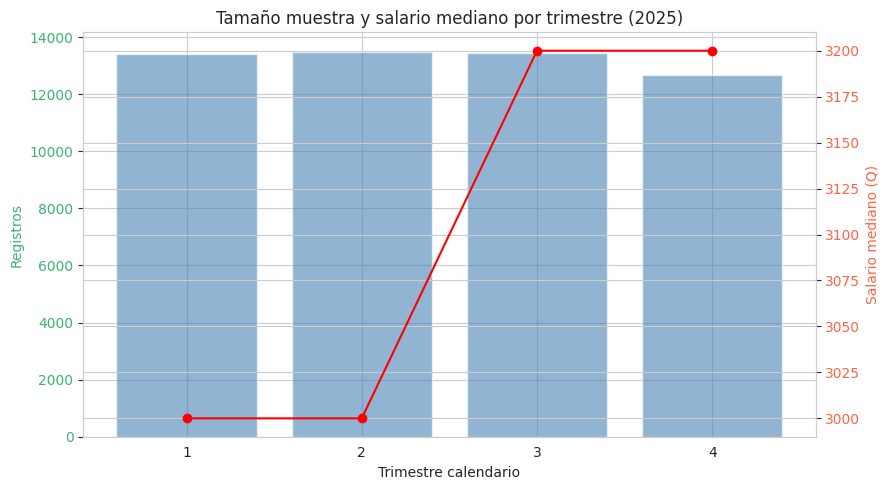

In [25]:
evol = (df_2025_f.groupBy("trimestre_calendario")
        .agg(
            F.count("*").alias("n"),
            F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
            F.mean("salario_mensual").alias("salario_medio")
        )
        .orderBy("trimestre_calendario")
        .toPandas())

print(f"{evol}\n")

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(evol["trimestre_calendario"].astype(str),
        evol["n"], color="steelblue", alpha=0.6, label="n")
ax1.set_xlabel("Trimestre calendario")
ax1.set_ylabel("Registros", color="mediumseagreen")
ax1.tick_params(axis="y", labelcolor="mediumseagreen")

ax2 = ax1.twinx()
ax2.plot(evol["trimestre_calendario"].astype(str), evol["salario_mediano"], color="red", marker="o", label="Salario mediano")
ax2.set_ylabel("Salario mediano (Q)", color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")

plt.title("Tamaño muestra y salario mediano por trimestre (2025)")
plt.tight_layout()
plt.show()

El n analítico tiene cierta estabilidad sin embargo el salrio mediano muestra una cuantas variaciones estacionales, en el 4to trimestre podemos ver como los aguinaldos y bonos de fin de año influenciaron llos resutlados.

# 3. Relaciones entre variables numéricas

In [26]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

print("=== MATRIZ DE CORRELACION ===")
vars_corr = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

#solo no nulos
df_corr = df_2025_f.select(*vars_corr).dropna()
print("Registros usados para correlacion:", df_corr.count())

#vedc
assembler = VectorAssembler(inputCols=vars_corr, outputCol="features")
df_vec = assembler.transform(df_corr).select("features")

#matriz correlacion
matriz = Correlation.corr(df_vec, "features", method="pearson").head()[0]
matriz_np = matriz.toArray()

print(matriz_np)

=== MATRIZ DE CORRELACION ===
Registros usados para correlacion: 53025
[[ 1.          0.14724926  0.17957441  0.07566511]
 [ 0.14724926  1.          0.48671276 -0.10537763]
 [ 0.17957441  0.48671276  1.         -0.06225561]
 [ 0.07566511 -0.10537763 -0.06225561  1.        ]]


Matriz de correlaciones:


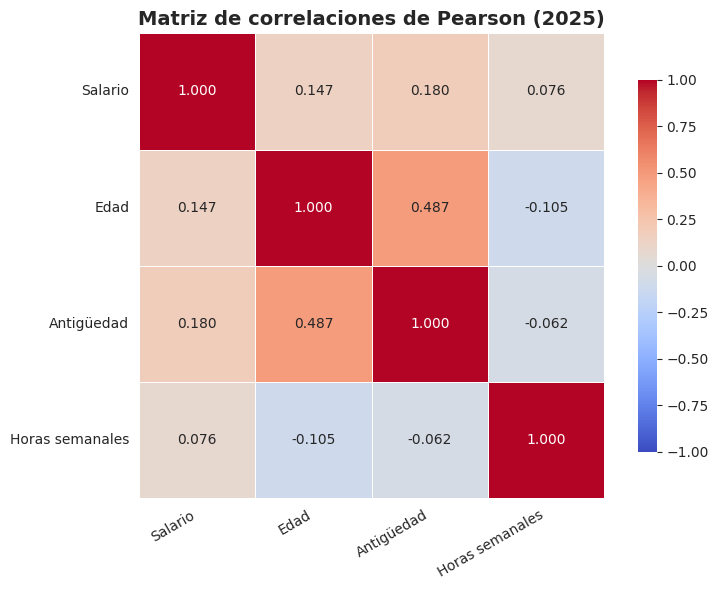

In [27]:
#etiquetas heatmap
etiquetas = ["Salario", "Edad", "Antigüedad", "Horas semanales"]

corr_df = pd.DataFrame(matriz_np, index=etiquetas, columns=etiquetas)
corr_df.round(3)

#heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlaciones de Pearson (2025)",fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== CORRELACIONES ===
Correlación con salario_mensual:
Antigüedad         0.180
Edad               0.147
Horas semanales    0.076
Name: Salario, dtype: float64


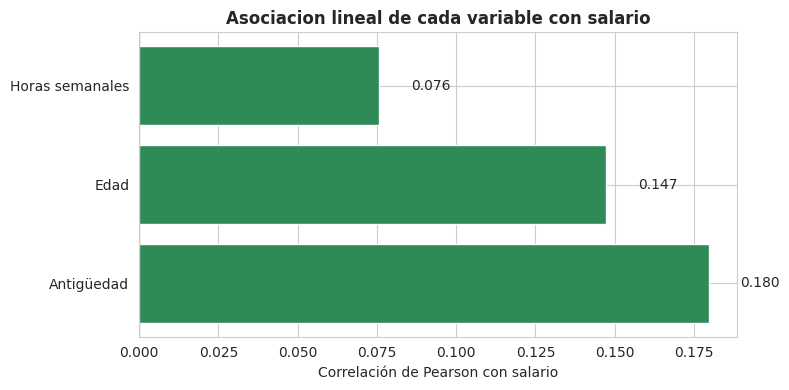

In [28]:
print("=== CORRELACIONES ===")

corr_salario = corr_df["Salario"].drop("Salario").sort_values(ascending=False)
print("Correlacion con salario_mensual:")
print(corr_salario.round(3))

#barras
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["seagreen" if v > 0 else "indianred" for v in corr_salario.values]
ax.barh(corr_salario.index, corr_salario.values, color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con salario")
ax.set_title("Asociacion lineal de cada variable con salario", fontsize=12, fontweight="bold")
for i, v in enumerate(corr_salario.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right")
plt.tight_layout()
plt.show()

Las variables con mayor asociacion mostraron ser Edad, Antigüedad y Horas semanales. Sin embarglo edad y antigüedad fueron las más fuertes, sin embargo ambas tienen una correlacioón fuerte debido a que de por si la edad indica una mayor cantidad de años en la trayectoria profesional pero esta no puede tomarse tan de cerca debido a que hay coasos diversos inlcuyendo que puede ser posible que alguien de mayor edad ingrese a trabajar.

La antigüedad de un trbajador en un sitio tambien peude afectar cosas como el el porcetaje de bonos.